# MachineLearningTask - chocolate_sales_2025_dataset.csv

**Tujuan**


1.   **Sales Prediction**: memprediksi nilai penjualan (Revenue) berdasarkan data yang tersedia
2.   **Customer Segmentation**: mengelompokkan pola penjualan menjadi beberapa kelompok

# Data Preprocessing & EDA

#### Import Library

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

##### Load Dataset
bertujuan memahami struktur dataset sebelum dianalisis lebih jauh


In [131]:
df = pd.read_csv('/content/chocolate_sales_2025_dataset.csv')
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
2,3,2025-02-17,Toblerone,Dark Chocolate,Australia,Supermarket,Digital Wallet,7.42,134,994.28
3,4,2025-11-29,Ferrero,Truffles,Italy,Convenience Store,Cash,18.28,112,2047.36
4,5,2025-03-23,Cadbury,Milk Chocolate,France,Convenience Store,Cash,18.21,92,1675.32


#### Data Understanding

###### Ukuran Dataset
Jumlah baris,
Jumlah kolom

In [132]:
df.shape

(500, 10)

###### Tipe Data
Jenis Data Tiap Kolom

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


###### Statistik Deskriptif

ringkasan statistik data numerik

In [134]:
df.describe()

,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,13.779860,104.938000,1433.391140
std,144.481833,6.484013,56.263998,1065.679386
min,1.000000,2.520000,5.000000,20.480000
25%,125.750000,8.592500,56.750000,562.545000
50%,250.500000,13.480000,108.500000,1197.225000
75%,375.250000,19.445000,150.250000,2072.812500
max,500.000000,25.000000,200.000000,4809.260000


###### Cek Missing Values

mengecek apakah ada data yang kosong atau hilang

In [135]:
df.isna().sum()

,0
Sale_ID,0
Date,0
Brand,0
Product_Type,0
Country,0
Sales_Channel,0
Payment_Method,0
Price_USD,0
Units_Sold,0
Revenue_USD,0


#### Ekstrak 'Month' dari 'Date'

Mengambil bulan dari tanggal transaksi. Tujuannya untuk bisa menganalisis pola penjualan per bulan.

Berguna untuk melihat apakah ada tren musiman dalam penjualan.

In [136]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month


#### Monthly Revenue Trend

Menunjukkan perubahan revenue setiap bulan

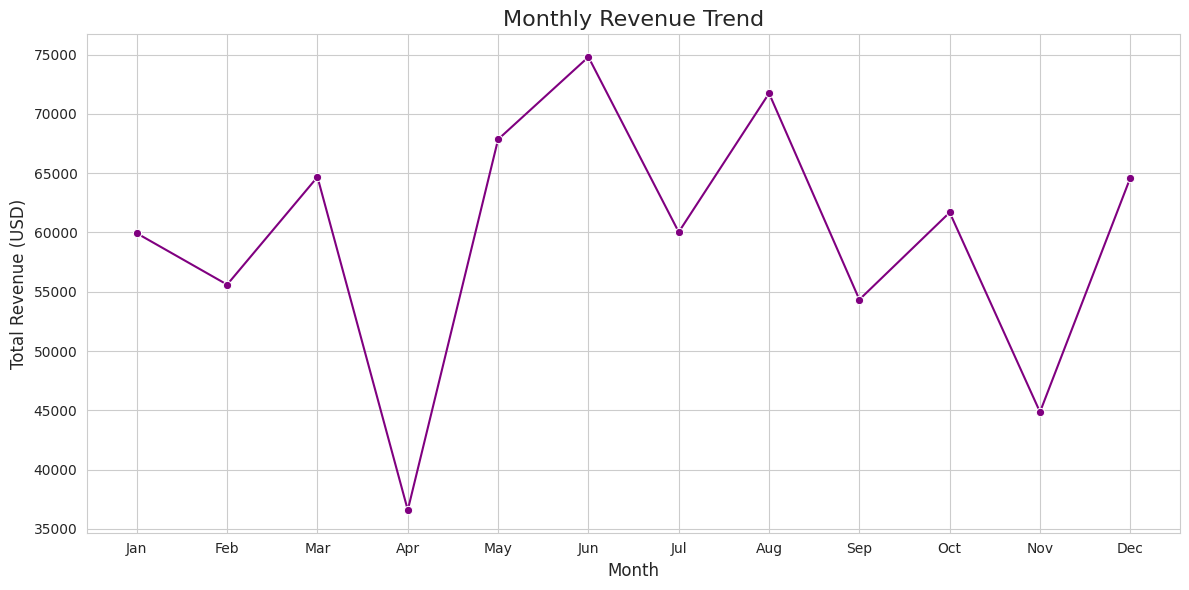

In [137]:
monthly_revenue = df.groupby('Month')['Revenue_USD'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Revenue_USD', data=monthly_revenue, marker='o', color='purple')
plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

#### Deteksi Outlier (Outlier Detection)

Mengecek data memiliki nilai ekstrem atau tidak

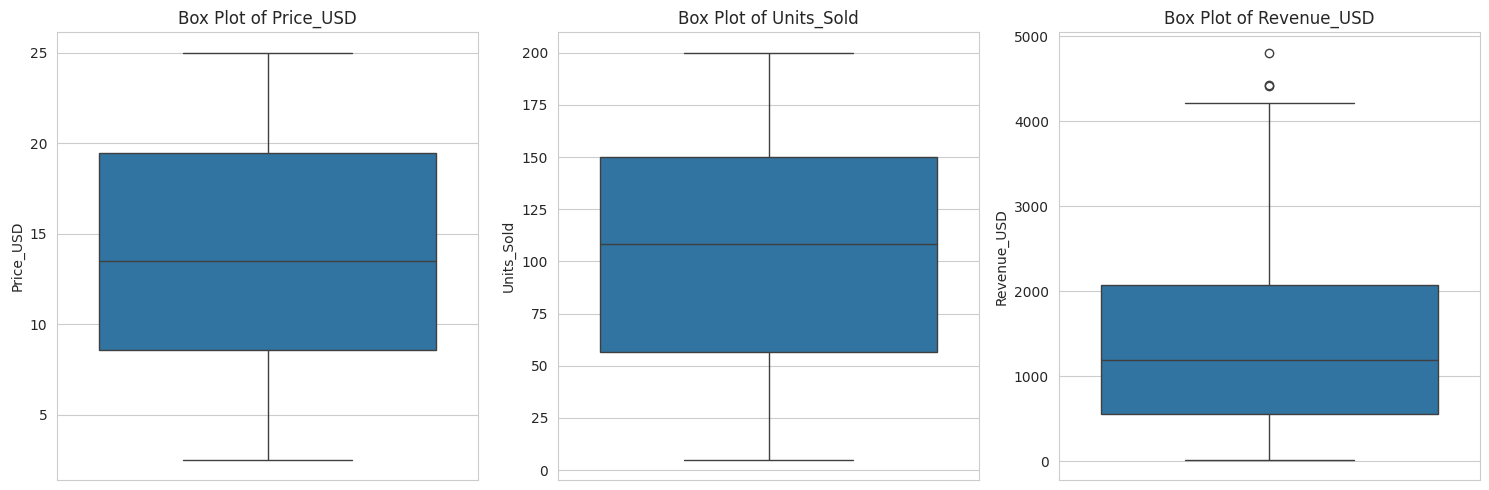


Quantitative Outlier Check (using IQR method for Revenue_USD):
Number of outliers in Revenue_USD: 3
Outliers in Revenue_USD (first 5 rows if any):


,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD,Month
72,73,2025-08-17,Nestle,Truffles,Canada,Convenience Store,Cash,22.69,195,4424.55,8
281,282,2025-07-21,Nestle,White Chocolate,Italy,Convenience Store,Digital Wallet,24.79,194,4809.26,7
484,485,2025-12-29,Toblerone,White Chocolate,France,Supermarket,Card,24.30,182,4422.60,12


In [138]:
numerical_cols_for_outliers = ['Price_USD', 'Units_Sold', 'Revenue_USD']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("\nQuantitative Outlier Check (using IQR method for Revenue_USD):")
Q1 = df['Revenue_USD'].quantile(0.25)
Q3 = df['Revenue_USD'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_revenue = df[(df['Revenue_USD'] < lower_bound) | (df['Revenue_USD'] > upper_bound)]

if not outliers_revenue.empty:
    print(f"Number of outliers in Revenue_USD: {len(outliers_revenue)}")
    print("Outliers in Revenue_USD (first 5 rows if any):")
    display(outliers_revenue.head())
else:
    print("No significant outliers detected in Revenue_USD using the IQR method.")

#### Correlation Heatmap

Melihat hubungan antar variabel numerik


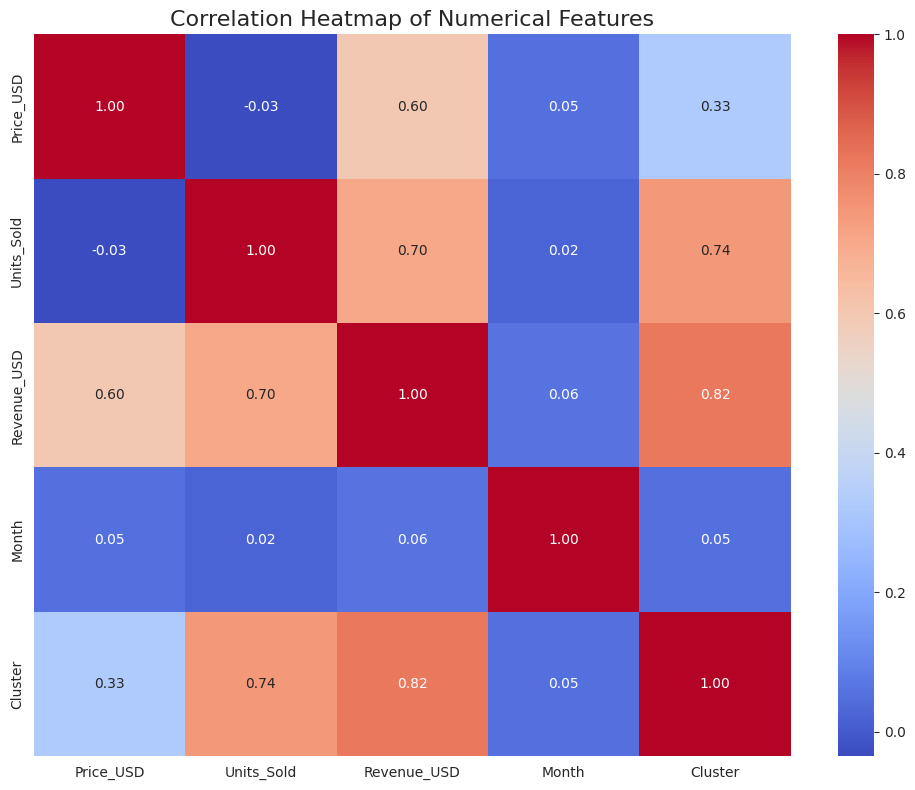

In [146]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).drop(columns=['Sale_ID']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

# Modelling & Evaluation


### Sales Prediction: Prepare Data for Regression

Melakukan encoding pada data kategorikal dan membagi data menjadi Training serta Testing set

In [140]:

# 1. Define the target variable 'y'
y = df['Revenue_USD']

# 2. Define the features 'X'
X = df.drop(columns=['Sale_ID', 'Date', 'Revenue_USD']).copy()

# 3. Perform one-hot encoding on categorical columns in X
categorical_cols = ['Brand', 'Product_Type', 'Country', 'Sales_Channel', 'Payment_Method']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nFirst 5 rows of X_train:")
display(X_train.head())
print("\nFirst 5 rows of y_train:")
display(y_train.head())

Shape of X_train: (400, 28)
Shape of X_test: (100, 28)
Shape of y_train: (400,)
Shape of y_test: (100,)

First 5 rows of X_train:


,Price_USD,Units_Sold,Month,Brand_Ferrero,Brand_Hershey,Brand_Lindt,Brand_Mars,Brand_Nestle,Brand_Toblerone,Product_Type_Chocolate Box,...,Country_Italy,Country_Saudi Arabia,Country_UAE,Country_UK,Country_USA,Sales_Channel_Online,Sales_Channel_Specialty Store,Sales_Channel_Supermarket,Payment_Method_Cash,Payment_Method_Digital Wallet
249,12.49,24,7,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
433,2.88,22,2,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
19,22.09,81,2,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,True,True,False
322,24.52,123,1,False,False,False,True,False,False,True,...,False,False,False,False,False,False,True,False,False,True
332,21.79,41,6,False,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,False,False



First 5 rows of y_train:


,Revenue_USD
249,299.76
433,63.36
19,1789.29
322,3015.96
332,893.39


### Sales Prediction: Train and Evaluate Regression Models

Menggunakan dua model:


1.   **Linear Regression**: Membuat garis terbaik yang menggambarkan hubungan antara input dan revenue
2.   **Random Forest**: Membuat banyak decision tree & Menggabungkan hasilnya


Evaluasi performa model menggunakan metrik seperti Mean Absolute Error (**MAE**: Rata-rata selisih antara prediksi dan nilai asli), Mean Squared Error (**MSE**: engukur error dengan memberikan penalti lebih besar pada error besar), Root Mean Squared Error (**RMSE**: Akar dari MSE sehingga kembali ke skala asli data), dan **R-squared**(Menunjukkan seberapa baik model menjelaskan data).

Pada grafiknya membandingkan:
nilai sebenarnya dengan nilai prediksi model


--- Training Linear Regression ---
Mean Absolute Error (MAE): 301.35
Mean Squared Error (MSE): 172220.48
Root Mean Squared Error (RMSE): 414.99
R-squared (R2): 0.86


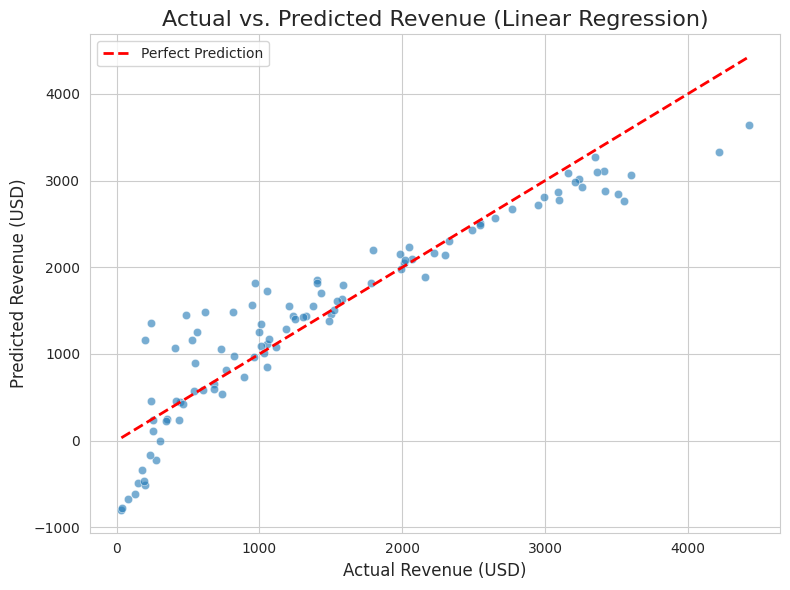


--- Training Random Forest Regressor ---
Mean Absolute Error (MAE): 73.61
Mean Squared Error (MSE): 11716.65
Root Mean Squared Error (RMSE): 108.24
R-squared (R2): 0.99


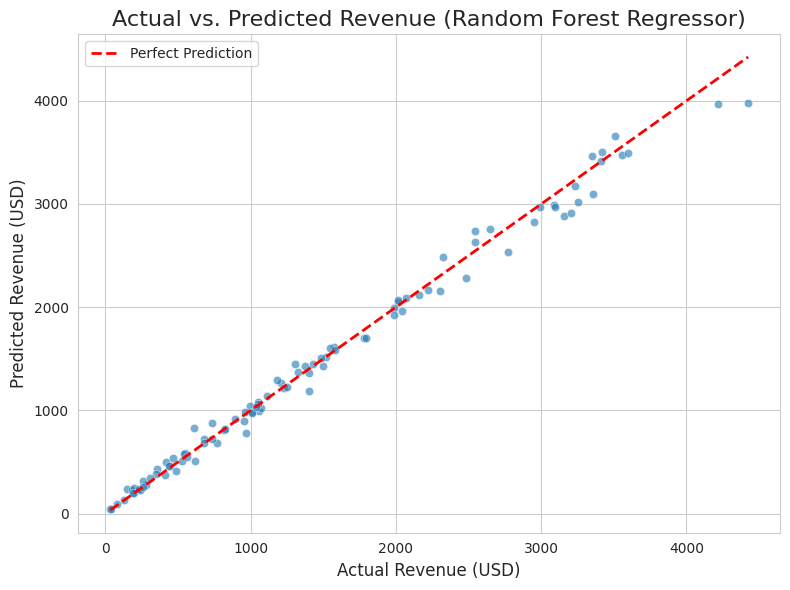

In [147]:
# Set a style for the plots
sns.set_style("whitegrid")

# 1. Create a dictionary of models to train
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42)
}

# 2. Iterate through each model
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    # a. Train the model
    model.fit(X_train, y_train)

    # b. Make predictions
    y_pred = model.predict(X_test)

    # c. Calculate and print evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2): {r2:.2f}")

    # d. Create a scatter plot for actual vs. predicted values
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f'Actual vs. Predicted Revenue ({name})', fontsize=16)
    plt.xlabel('Actual Revenue (USD)', fontsize=12)
    plt.ylabel('Predicted Revenue (USD)', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Dari 2 perbandingan model tersebut dapat diambil kesimpulan bahwa train menggunakan Random Forest lebih bagus dibanding dengan Linear Regression, juga menunjukkan bahwa jumlah unit yang terjual memiliki pengaruh besar terhadap revenue penjualan

### Customer Segmentation (Clustering)

Menggunakan unsupervised learning (tidak diberi target)

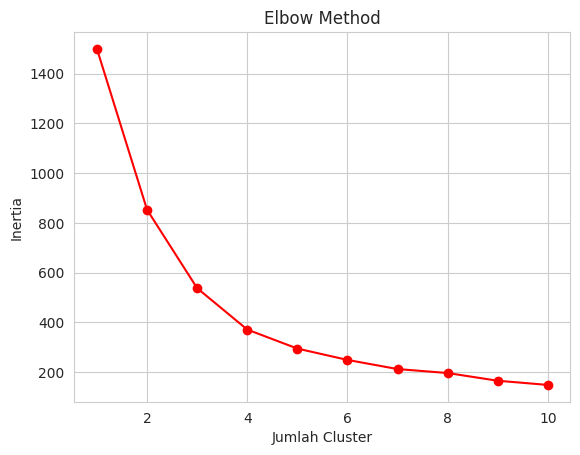

In [142]:
cluster_data = df[['Price_USD','Units_Sold','Revenue_USD']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

inertia = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o', color='red')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.show()



Elbow Method digunakan untuk menentukan jumlah cluster yang paling optimal (diambil 3).

In [143]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

score = silhouette_score(scaled_data, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.3998760134564226


Pada silhouette Score sebenarnya cluster 4 memiliki nilai silhouette 0.4142, namun disini saya tetap memilih hasil akhir di cluster 3 (0.3999) karena akan lebih simpel dalam segmentasinya ketimbang 4. (Jika 3: Rendah, Sedang, Besar), (Jika 4: Rendah, Agak Rendah, Sedang, Tinggi). Toh jg sebenarnya dari nilai silhouette score antara 3 dan 4 hanya memiliki selisih 0.014 yang dimana itu tidak terlalu berpengaruh signifikan

Berikut visualisasi clusteringnya

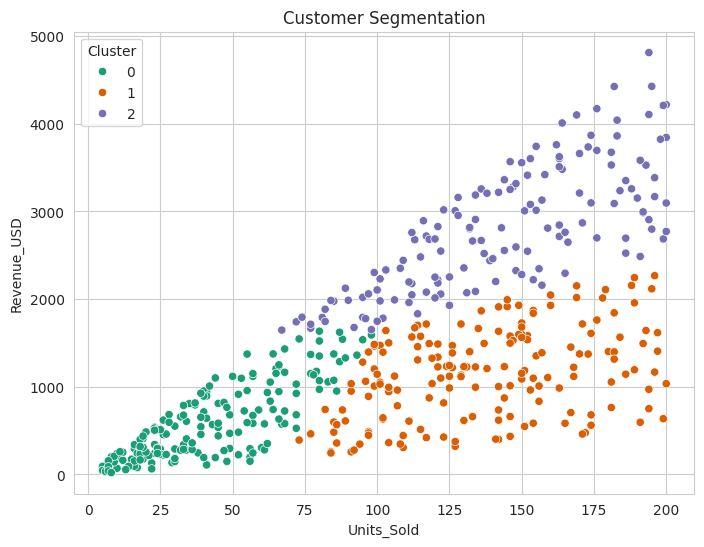

In [144]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Units_Sold',
    y='Revenue_USD',
    hue='Cluster',
    palette='Dark2',
    data=df
)


plt.title("Customer Segmentation")
plt.show()

Berikut rata-rata nilai dari setiap cluster

In [145]:
df.groupby('Cluster')[['Revenue_USD','Units_Sold','Price_USD']].mean()


,Revenue_USD,Units_Sold,Price_USD
Cluster,,,
0,587.278814,41.627119,14.043842
1,1146.080341,136.886364,8.446932
2,2796.170612,142.918367,19.847007


Dari tabel ini terlihat bahwa: cluster 0 masuk

1.   cluster 0: tipikal cust. yang beli sedikit, tapi beli produk di harga middle
2.   cluster 1: tipikal cust. beli banyak, tapi beli produk di harga low
3.   cluster 2: tipikal cust. beli banyak, dan belinya produk mahal
